# Tech Talent Salary Prediction (Multivariate Linear Regression)

My mission is to use technology to help solve unemployment, education and access to
tech problems. One useful feature for a talent platform is telling a member what salary
their profile is worth on the market, so they can see what upskilling or changing role
is actually worth to them.

This notebook builds that model. The task is regression: predict `salary_in_usd`
(a continuous value).

**Dataset:** Data Science / Tech Job Salaries (3,755 rows, 11 columns). It covers 93 job
titles across 78 countries for the years 2020 to 2023, with a mix of numeric and
categorical columns, so it has both volume and variety. The source is noted in the README.

Plan:
1. Load and explore the data.
2. Engineer and drop features, then standardise.
3. Train and compare 4 models: two gradient descent linear regressors (scikit-learn
   `SGDRegressor` and a batch gradient descent version written from scratch), a Random
   Forest, and a Decision Tree.
4. Plot the train vs test loss curves and the best fit line.
5. Save the model with the lowest loss and make a single prediction (reused by the API).

In [2]:
import os, json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")

# local path in the repo, with a GitHub fallback so the notebook also runs on Colab
DATA_PATH = "data/ds_salaries.csv"
DATA_URL = "https://raw.githubusercontent.com/SHYAKA-Aime/Regression-Analysis-Mobile-Application/main/summative/linear_regression/data/ds_salaries.csv"

# save next to the API when running from the repo, otherwise save in a local folder (Colab)
MODEL_DIR = "../API/model" if os.path.isdir("../API") else "model"
os.makedirs(MODEL_DIR, exist_ok=True)

## 1. Load and inspect the data

In [3]:
df = pd.read_csv(DATA_PATH if os.path.exists(DATA_PATH) else DATA_URL)
print("Shape:", df.shape)
df.head()

Shape: (3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [5]:
# check for missing values and duplicates before doing anything else
print("Missing values:\n", df.isnull().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
df.describe(include="all").T

Missing values:
 work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Exact duplicate rows: 1171


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,3755.0,NaN,NaN,NaN,2022.373635,0.691448,2020.0,2022.0,2022.0,2023.0,2023.0
experience_level,3755,4,SE,2516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,3755,4,FT,3718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,3755,93,Data Engineer,1040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,3755.0,NaN,NaN,NaN,190695.571771,671676.500508,6000.0,100000.0,138000.0,180000.0,30400000.0
salary_currency,3755,20,USD,3224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,3755.0,NaN,NaN,NaN,137570.38988,63055.625278,5132.0,95000.0,135000.0,175000.0,450000.0
employee_residence,3755,78,US,3004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,3755.0,NaN,NaN,NaN,46.271638,48.58905,0.0,0.0,0.0,100.0,100.0
company_location,3755,72,US,3040,NaN,NaN,NaN,NaN,NaN,NaN,NaN


There are no missing values. Some rows are exact duplicates, which is expected here
(different people with the same profile and pay), so I keep them as real observations.

## 2. Exploratory visualisations

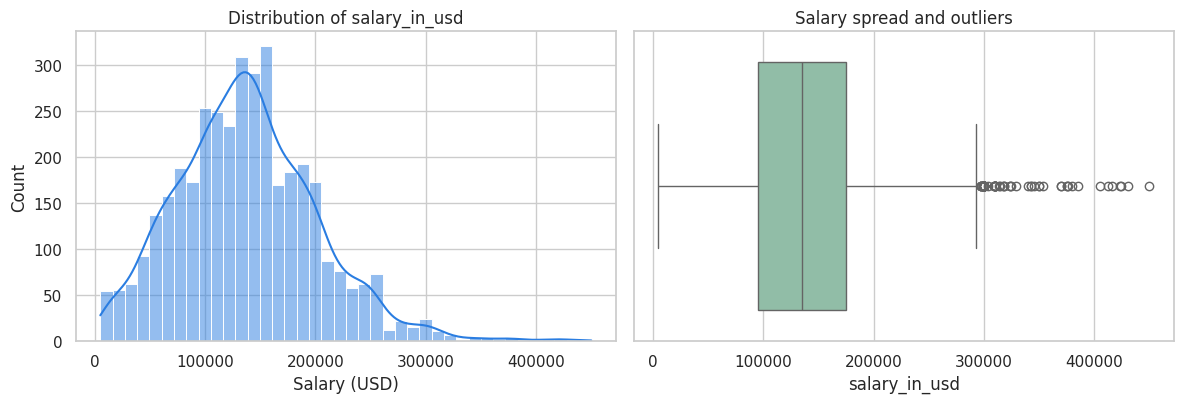

In [6]:
# how is the target spread out?
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(df["salary_in_usd"], bins=40, kde=True, ax=ax[0], color="#2a7de1")
ax[0].set_title("Distribution of salary_in_usd")
ax[0].set_xlabel("Salary (USD)")
sns.boxplot(x=df["salary_in_usd"], ax=ax[1], color="#8ac4a7")
ax[1].set_title("Salary spread and outliers")
plt.tight_layout(); plt.show()

Salaries are skewed to the right, with a long tail above 300k and a median around 135k.
A linear model gets pulled towards that tail, which is something to keep in mind when
reading the loss later.

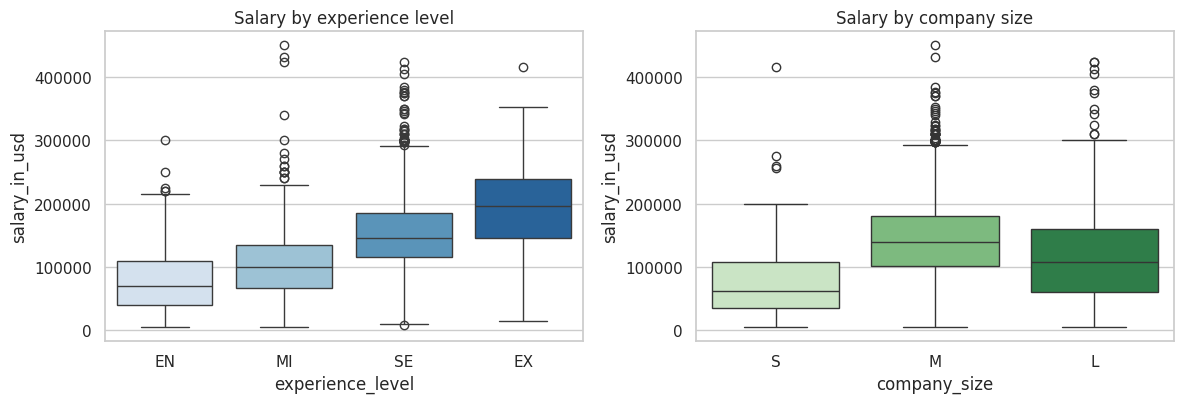

In [8]:
# does salary move with experience level and company size?
order_exp = ["EN", "MI", "SE", "EX"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.boxplot(data=df, x="experience_level", y="salary_in_usd", order=order_exp, ax=ax[0], palette="Blues")
ax[0].set_title("Salary by experience level")
sns.boxplot(data=df, x="company_size", y="salary_in_usd", order=["S","M","L"], ax=ax[1], palette="Greens")
ax[1].set_title("Salary by company size")
plt.tight_layout(); plt.show()

Salary rises steadily from entry (EN) to executive (EX), so experience level is the
strongest driver and has a natural order. Medium and large companies pay more than small
ones. Both of these are good candidates for ordinal encoding.

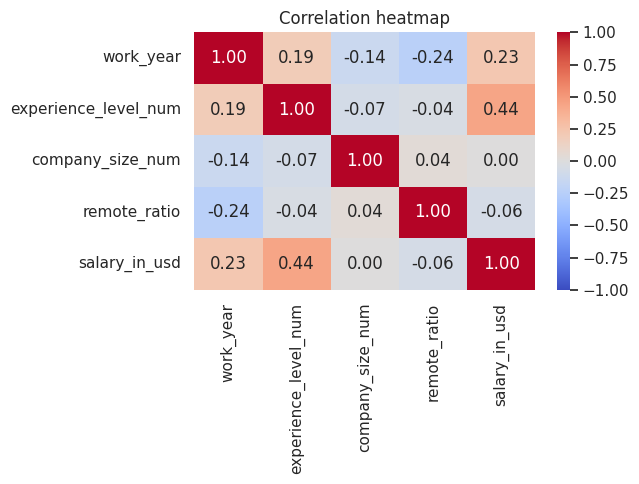

In [9]:
# correlation between the numeric and orderable features
tmp = df.copy()
tmp["experience_level_num"] = tmp["experience_level"].map({"EN":1,"MI":2,"SE":3,"EX":4})
tmp["company_size_num"] = tmp["company_size"].map({"S":1,"M":2,"L":3})
corr = tmp[["work_year","experience_level_num","company_size_num","remote_ratio","salary_in_usd"]].corr()
plt.figure(figsize=(6.5,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation heatmap")
plt.tight_layout(); plt.show()

Experience level has the strongest positive correlation with salary, so it is our lead
feature. Work year is mildly positive (pay drifted up over time). Remote ratio is close to
zero, so being fully remote does not really raise pay in this data. I keep it but expect a
small weight.

## 3. Feature engineering

What I drop and what I keep, with the reasoning:

| Column | Decision | Reason |
|---|---|---|
| `salary`, `salary_currency` | drop | `salary_in_usd` is computed from them, so keeping them leaks the target |
| `employee_residence` | drop | almost the same information as `company_location` |
| `job_title` (93 values) | group into `job_category` (6 groups) | too many values to one-hot directly |
| `company_location` (78 values) | keep top 6, bucket the rest as Other | the US alone is 81% of rows |
| `experience_level`, `company_size` | ordinal encode | they have a natural order |
| `employment_type` and the grouped columns | one-hot encode | nominal, low cardinality after grouping |
| `work_year`, `remote_ratio` | standardise | numeric |

The final model uses 7 input features, which is exactly what the API and the app expose.

In [10]:
def engineer_features(df):
    """Feature engineering shared with the API. Safe to run on the raw or already
    engineered data, because missing columns are skipped."""
    df = df.copy()
    df = df.drop(columns=["salary", "salary_currency", "employee_residence"], errors="ignore")

    def job_cat(t):
        t = str(t).lower()
        if any(k in t for k in ["manager", "lead", "head", "director", "principal"]):
            return "Management"
        if any(k in t for k in ["machine learning", "ml engineer", "ai ", " ai", "deep learning", "computer vision", "nlp"]):
            return "ML/AI Engineer"
        if any(k in t for k in ["engineer", "developer", "architect"]):
            return "Data Engineer"
        if any(k in t for k in ["scientist", "research"]):
            return "Data Scientist"
        if any(k in t for k in ["analyst", "analytics"]):
            return "Data Analyst"
        return "Other"

    if "job_title" in df.columns:
        df["job_category"] = df["job_title"].apply(job_cat)
        df = df.drop(columns=["job_title"])

    top_locs = ["US", "GB", "CA", "ES", "IN", "DE"]
    if "company_location" in df.columns:
        df["company_location_grp"] = df["company_location"].apply(lambda x: x if x in top_locs else "Other")
        df = df.drop(columns=["company_location"])
    return df

data = engineer_features(df)
print("Columns after engineering:", list(data.columns))
print("job_category:", data["job_category"].value_counts().to_dict())
print("company_location_grp:", data["company_location_grp"].value_counts().to_dict())
data.head()

Columns after engineering: ['work_year', 'experience_level', 'employment_type', 'salary_in_usd', 'remote_ratio', 'company_size', 'job_category', 'company_location_grp']
job_category: {'Data Engineer': 1370, 'Data Scientist': 992, 'Data Analyst': 681, 'ML/AI Engineer': 471, 'Management': 196, 'Other': 45}
company_location_grp: {'US': 3040, 'Other': 265, 'GB': 172, 'CA': 87, 'ES': 77, 'IN': 58, 'DE': 56}


,work_year,experience_level,employment_type,salary_in_usd,remote_ratio,company_size,job_category,company_location_grp
0,2023,SE,FT,85847,100,L,Management,ES
1,2023,MI,CT,30000,100,S,ML/AI Engineer,US
2,2023,MI,CT,25500,100,S,ML/AI Engineer,US
3,2023,SE,FT,175000,100,M,Data Scientist,CA
4,2023,SE,FT,120000,100,M,Data Scientist,CA


## 4. Train/test split and standardisation

In [11]:
TARGET = "salary_in_usd"
NUMERIC  = ["work_year", "remote_ratio"]
ORDINAL  = ["experience_level", "company_size"]
NOMINAL  = ["employment_type", "job_category", "company_location_grp"]
FEATURES = NUMERIC + ORDINAL + NOMINAL

X = data[FEATURES].copy()
y = data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

# scaling lives inside the pipeline so the same transform is applied at prediction time
# and the gradient descent models converge properly
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC),
    ("ord", Pipeline([
        ("enc", OrdinalEncoder(categories=[["EN","MI","SE","EX"], ["S","M","L"]],
                               handle_unknown="use_encoded_value", unknown_value=-1)),
        ("scale", StandardScaler()),
    ]), ORDINAL),
    ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL),
])
preprocessor

Train: (3004, 7)  Test: (751, 7)


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['work_year', 'remote_ratio']),
                                ('ord',
                                 Pipeline(steps=[('enc',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1)),
                                                 ('scale', StandardScaler())]),
                                 ['experience_level', 'company_size']),
                                ('nom',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['employment_type', 'job_category',
                                  'company_location_grp'])])

## 5. Batch gradient descent linear regression (from scratch)

This is the first gradient descent model. Writing it by hand lets me record the train and
test loss at every epoch, which gives a clean loss curve.

In [12]:
class BatchGDRegressor(BaseEstimator, RegressorMixin):
    """Linear regression trained with full batch gradient descent on the MSE loss."""

    def __init__(self, lr=0.1, n_epochs=800):
        self.lr = lr
        self.n_epochs = n_epochs

    def fit(self, X, y, X_val=None, y_val=None):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        # scale the target internally for stability, undo it on predict
        self._y_mean, self._y_std = y.mean(), y.std() + 1e-12
        y_s = (y - self._y_mean) / self._y_std

        n, m = X.shape
        self.w_ = np.zeros(m)
        self.b_ = 0.0
        self.train_loss_, self.val_loss_ = [], []
        for _ in range(self.n_epochs):
            pred = X @ self.w_ + self.b_
            err = pred - y_s
            self.w_ -= self.lr * (2 / n) * (X.T @ err)
            self.b_ -= self.lr * (2 / n) * err.sum()
            # store loss in real USD units so the curve is easy to read
            self.train_loss_.append(mean_squared_error(y, self._unscale(pred)))
            if X_val is not None:
                vp = np.asarray(X_val, dtype=float) @ self.w_ + self.b_
                self.val_loss_.append(mean_squared_error(np.asarray(y_val).ravel(), self._unscale(vp)))
        return self

    def _unscale(self, s):
        return s * self._y_std + self._y_mean

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._unscale(X @ self.w_ + self.b_)

# fit on preprocessed arrays so we can pass a validation set for the loss curve
pre = clone(preprocessor)
Xtr = pre.fit_transform(X_train)
Xte = pre.transform(X_test)

gd = BatchGDRegressor(lr=0.1, n_epochs=800)
gd.fit(Xtr, y_train, X_val=Xte, y_val=y_test)
print(f"Batch GD test RMSE: {np.sqrt(gd.val_loss_[-1]):,.0f} USD")

Batch GD test RMSE: 48,672 USD


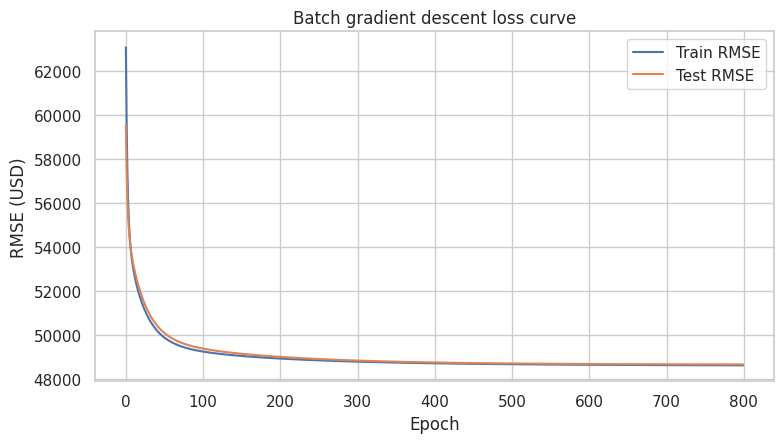

In [13]:
plt.figure(figsize=(8,4.6))
plt.plot(np.sqrt(gd.train_loss_), label="Train RMSE")
plt.plot(np.sqrt(gd.val_loss_), label="Test RMSE")
plt.xlabel("Epoch"); plt.ylabel("RMSE (USD)")
plt.title("Batch gradient descent loss curve")
plt.legend(); plt.tight_layout(); plt.show()

Train and test RMSE fall together and then flatten out, so the model converged and there
is no big gap between them (no overfitting). The floor around 50k RMSE is the noise in salaries
that a linear model cannot explain, which is why I also try the tree and ensemble models.

## 6. Second gradient descent model: scikit-learn SGDRegressor

This one uses stochastic gradient descent. I track its per epoch loss with `partial_fit`.

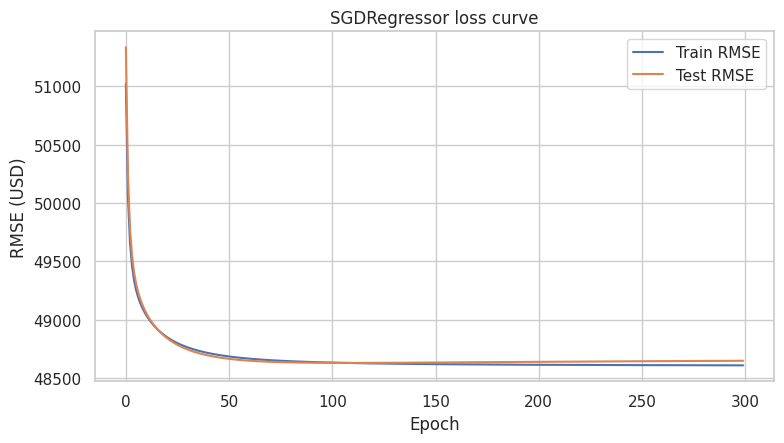

SGD test RMSE: 48,650 USD


In [14]:
sgd_curve = SGDRegressor(loss="squared_error", penalty="l2", alpha=1e-4,
                         learning_rate="invscaling", eta0=0.01, random_state=42)
y_mean, y_std = y_train.mean(), y_train.std()
ytr_s = (y_train - y_mean) / y_std
tr_hist, te_hist = [], []
for _ in range(300):
    sgd_curve.partial_fit(Xtr, ytr_s)
    tr_hist.append(mean_squared_error(y_train, sgd_curve.predict(Xtr)*y_std + y_mean))
    te_hist.append(mean_squared_error(y_test,  sgd_curve.predict(Xte)*y_std + y_mean))

plt.figure(figsize=(8,4.6))
plt.plot(np.sqrt(tr_hist), label="Train RMSE")
plt.plot(np.sqrt(te_hist), label="Test RMSE")
plt.xlabel("Epoch"); plt.ylabel("RMSE (USD)")
plt.title("SGDRegressor loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print(f"SGD test RMSE: {np.sqrt(te_hist[-1]):,.0f} USD")

## 7. Build all 4 models and tune the linear ones

Each model is a full pipeline (preprocessing then estimator) so preprocessing is identical
and the saved file is self contained. The two linear models are tuned with a small grid search.

In [15]:
models = {}

# 1) SGD linear regression, tuned
sgd_pipe = Pipeline([("pre", clone(preprocessor)),
                     ("model", SGDRegressor(random_state=42, max_iter=2000, early_stopping=True))])
sgd_grid = GridSearchCV(
    sgd_pipe,
    {"model__alpha": [1e-4, 1e-3, 1e-2],
     "model__penalty": ["l2", "l1"],
     "model__eta0": [0.005, 0.01],
     "model__learning_rate": ["invscaling", "adaptive"]},
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
sgd_grid.fit(X_train, y_train)
models["SGD Linear Regression (GD)"] = sgd_grid.best_estimator_
print("Best SGD params:", sgd_grid.best_params_)

# 2) batch GD linear regression from scratch
bgd_pipe = Pipeline([("pre", clone(preprocessor)),
                     ("model", BatchGDRegressor(lr=0.1, n_epochs=800))])
bgd_pipe.fit(X_train, y_train)
models["Batch GD Linear Regression"] = bgd_pipe

# 3) Random Forest (ensemble)
rf_pipe = Pipeline([("pre", clone(preprocessor)),
                    ("model", RandomForestRegressor(n_estimators=300, max_depth=12,
                                                    min_samples_leaf=3, random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
models["Random Forest"] = rf_pipe

# 4) Decision Tree
dt_pipe = Pipeline([("pre", clone(preprocessor)),
                    ("model", DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42))])
dt_pipe.fit(X_train, y_train)
models["Decision Tree"] = dt_pipe

print("Trained:", list(models.keys()))

Best SGD params: {'model__alpha': 0.0001, 'model__eta0': 0.005, 'model__learning_rate': 'adaptive', 'model__penalty': 'l2'}
Trained: ['SGD Linear Regression (GD)', 'Batch GD Linear Regression', 'Random Forest', 'Decision Tree']


## 8. Compare the models on the loss metric

In [16]:
def evaluate(name, model):
    pr_tr, pr_te = model.predict(X_train), model.predict(X_test)
    return {
        "Model": name,
        "Train RMSE": np.sqrt(mean_squared_error(y_train, pr_tr)),
        "Test RMSE":  np.sqrt(mean_squared_error(y_test,  pr_te)),
        "Test MAE":   mean_absolute_error(y_test, pr_te),
        "Test R2":    r2_score(y_test, pr_te),
    }

results = pd.DataFrame([evaluate(n, m) for n, m in models.items()]).sort_values("Test RMSE").reset_index(drop=True)
results

,Model,Train RMSE,Test RMSE,Test MAE,Test R2
0,SGD Linear Regression (GD),48646.565047,48644.640819,37236.407733,0.400601
1,Batch GD Linear Regression,48630.292182,48672.301000,37268.651686,0.399919
2,Random Forest,45251.874220,48968.114535,37240.997888,0.392603
3,Decision Tree,47104.447146,49816.511473,37933.879219,0.371374


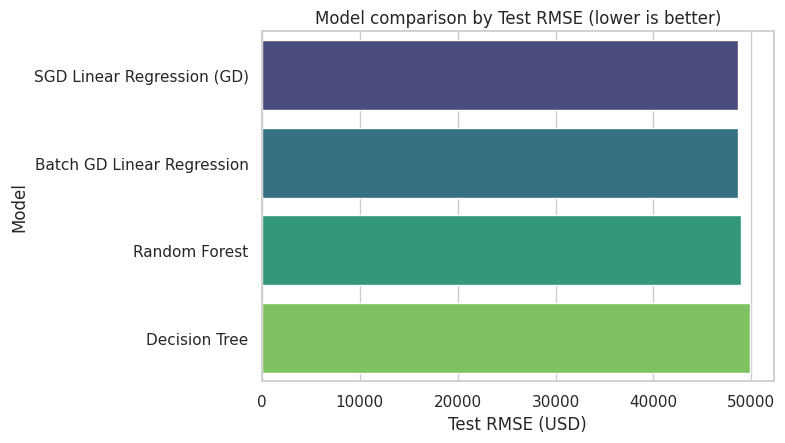

In [17]:
plt.figure(figsize=(8,4.6))
sns.barplot(data=results, x="Test RMSE", y="Model", palette="viridis")
plt.title("Model comparison by Test RMSE (lower is better)")
plt.xlabel("Test RMSE (USD)")
plt.tight_layout(); plt.show()

In [18]:
best_name = results.iloc[0]["Model"]
best_model = models[best_name]
print(f"Best model (lowest Test RMSE): {best_name}")
print(f"  Test RMSE = {results.iloc[0]['Test RMSE']:,.0f} USD | Test R2 = {results.iloc[0]['Test R2']:.3f}")

Best model (lowest Test RMSE): SGD Linear Regression (GD)
  Test RMSE = 48,645 USD | Test R2 = 0.401


I pick the model with the lowest test RMSE, since that is the loss metric and it also
checks against overfitting (small gap between train and test). That model is saved and served.

## 9. Best fit line, before and after

The model is multivariate, so I show the fitted line against the main feature,
experience level. On the left is the raw data, on the right is the same data with the
linear model's prediction line laid over it.

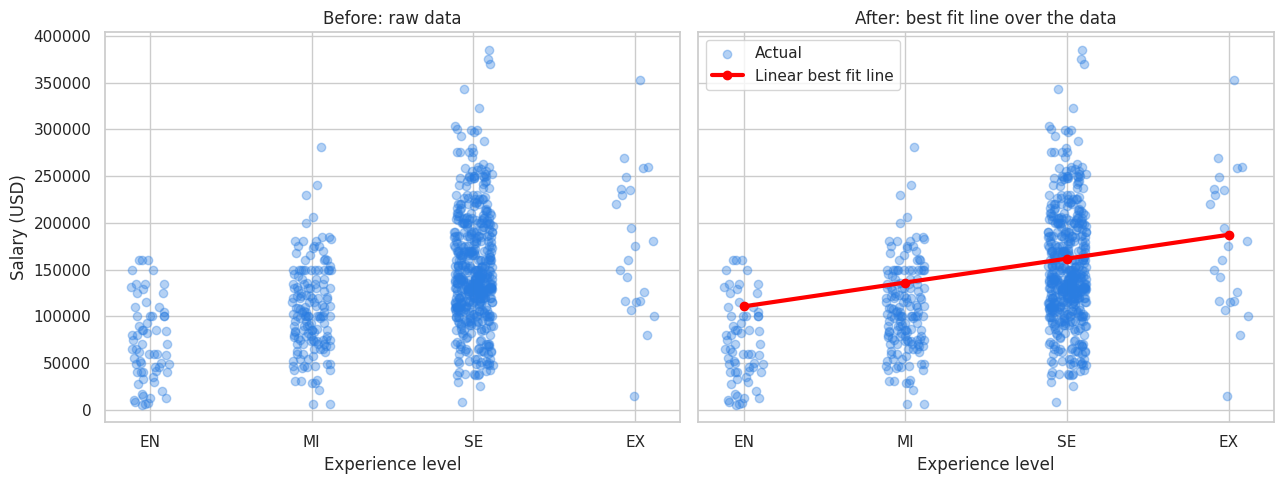

In [19]:
lin_model = models["SGD Linear Regression (GD)"]
exp_map = {"EN":1, "MI":2, "SE":3, "EX":4}
x_num = X_test["experience_level"].map(exp_map).astype(float)
jitter = np.random.uniform(-0.12, 0.12, size=len(x_num))

# hold every other feature at a typical value and vary only experience level
typical = X_train.mode().iloc[0]
line_rows = []
for lvl in ["EN","MI","SE","EX"]:
    r = typical.copy(); r["experience_level"] = lvl; line_rows.append(r)
line_pred = lin_model.predict(pd.DataFrame(line_rows))

fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ax[0].scatter(x_num + jitter, y_test, alpha=0.35, color="#2a7de1")
ax[0].set_title("Before: raw data")
ax[0].set_xticks([1,2,3,4]); ax[0].set_xticklabels(["EN","MI","SE","EX"])
ax[0].set_xlabel("Experience level"); ax[0].set_ylabel("Salary (USD)")

ax[1].scatter(x_num + jitter, y_test, alpha=0.35, color="#2a7de1", label="Actual")
ax[1].plot([1,2,3,4], line_pred, color="red", lw=3, marker="o", label="Linear best fit line")
ax[1].set_title("After: best fit line over the data")
ax[1].set_xticks([1,2,3,4]); ax[1].set_xticklabels(["EN","MI","SE","EX"])
ax[1].set_xlabel("Experience level"); ax[1].legend()
plt.tight_layout(); plt.show()

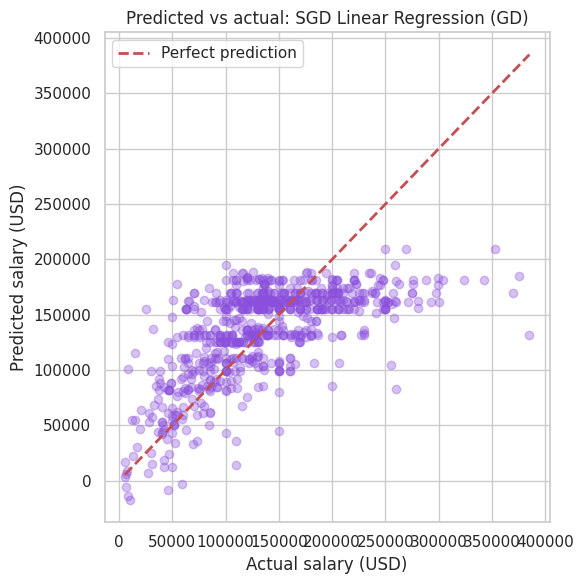

In [20]:
# predicted vs actual for the best model
pred_best = best_model.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_best, alpha=0.35, color="#8a4fdc")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
plt.xlabel("Actual salary (USD)"); plt.ylabel("Predicted salary (USD)")
plt.title(f"Predicted vs actual: {best_name}")
plt.legend(); plt.tight_layout(); plt.show()

## 10. Predict a single row (reused by the API in Task 2)

In [21]:
# take one row from the test set and predict it
one_row = X_test.iloc[[0]]
actual = y_test.iloc[0]
predicted = float(best_model.predict(one_row)[0])
print("Input profile:")
print(one_row.T)
print(f"\nActual salary:    ${actual:,.0f}")
print(f"Predicted salary: ${predicted:,.0f}")
print(f"Absolute error:   ${abs(actual-predicted):,.0f}")

Input profile:
                                2148
work_year                       2022
remote_ratio                     100
experience_level                  SE
company_size                       M
employment_type                   FT
job_category          ML/AI Engineer
company_location_grp              CA

Actual salary:    $168,000
Predicted salary: $152,317
Absolute error:   $15,683


## 11. Save the best model and its metadata (used by the API)

In [22]:
joblib.dump(best_model, f"{MODEL_DIR}/best_model.pkl")

metadata = {
    "best_model": best_name,
    "target": TARGET,
    "features": FEATURES,
    "metrics": results.set_index("Model").round(2).to_dict(orient="index"),
    "allowed_values": {
        "experience_level": ["EN", "MI", "SE", "EX"],
        "employment_type":  ["FT", "PT", "CT", "FL"],
        "company_size":     ["S", "M", "L"],
        "job_category":     ["Data Engineer","Data Scientist","Data Analyst","ML/AI Engineer","Management","Other"],
        "company_location_grp": ["US","GB","CA","ES","IN","DE","Other"],
        "remote_ratio":     [0, 50, 100],
    },
    "ranges": {"work_year": [2020, 2027], "remote_ratio": [0, 100]},
}
with open(f"{MODEL_DIR}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# keep a copy of the training data next to the model so the API can retrain
data.assign(**{TARGET: y}).to_csv(f"{MODEL_DIR}/training_data.csv", index=False)
print("Saved best_model.pkl, model_metadata.json and training_data.csv to", MODEL_DIR)

Saved best_model.pkl, model_metadata.json and training_data.csv to model


## Summary

I compared four models on test RMSE: two gradient descent linear regressors, a Random Forest,
and a Decision Tree. The loss curves show the linear models converge cleanly. The scores are
close, and the SGD linear model has the lowest test RMSE, so it is saved as `best_model.pkl`.
Because the saved pipeline includes all the preprocessing, the API and the app only need to
send raw feature values to get a prediction.